In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [56]:
data_30 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_30_quantile1.csv')
data_31 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_31_quantile1.csv')
data_32= pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_32_quantile1.csv')
data_33 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_33_quantile1.csv')
data_99 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_99_quantile1.csv')


/tmp/ipykernel_333389/4014447211.py:1: DtypeWarning: Columns (325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368) have mixed types. Specify dtype option on import or set low_memory=False.
  data_30 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_30_quantile1.csv')
/tmp/ipykernel_333389/4014447211.py:2: DtypeWarning: Columns (365,366,367,368) have mixed types. Specify dtype option on import or set low_memory=False.
  data_31 = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/phase2_31_quantile1.csv')
/tmp/ipykernel_333389/4014447211.py:3: DtypeWarning: Columns (325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368) have mixed types. Specify dtype optio

In [71]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')
#data = pd.concat([data_30, data_31, data_32, data_33, data_99])

/tmp/ipykernel_333389/1757762578.py:1: DtypeWarning: Columns (462,463) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2.csv')


In [5]:
data

,Unnamed: 0,plate,measurement,start_date,light_regime,dark_threshold,light_threshold,num_frames,i,j,...,light_status_84,light_status_85,light_status_86,light_status_87,light_status_88,light_status_89,light_status_90,y2_slope_light,y2_slope_dark,y2_slope
0,57303,30v1,M6,2024-06-13,20h_ML,15.536611,20.552547,92,13,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57293,30v1,M6,2024-06-13,20h_ML,15.536611,20.552547,92,13,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,57039,30v1,M6,2024-06-13,20h_ML,15.536611,20.552547,92,2,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,57029,30v1,M6,2024-06-13,20h_ML,15.536611,20.552547,92,2,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,57020,30v1,M6,2024-06-13,20h_ML,15.536611,20.552547,92,2,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6838,80836,99v2,M6,2024-11-22,10min-10min,15.794447,22.317526,172,5,0,...,light,dark,dark,NaN,NaN,NaN,NaN,-0.002922,0.000202,-0.002922
6839,80835,99v2,M6,2024-11-22,10min-10min,15.794447,22.317526,172,4,23,...,light,dark,dark,NaN,NaN,NaN,NaN,-0.002625,-0.001051,-0.002625
6840,80834,99v2,M6,2024-11-22,10min-10min,15.794447,22.317526,172,4,22,...,light,dark,dark,NaN,NaN,NaN,NaN,-0.002405,-0.000895,-0.002405
6841,80843,99v2,M6,2024-11-22,10min-10min,15.794447,22.317526,172,5,7,...,light,dark,dark,NaN,NaN,NaN,NaN,-0.002109,0.000103,-0.002109


In [ ]:
from Scripts_Imane import Format_Data
data = Format_Data.get_format_data(data)

In [72]:
import os
import pandas as pd
import numpy as np

folder = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/exemples of light on light off'
data = data.copy()

#use le fichier le plus récent pour chaque (plate, light_regime)
latest_files = {}

for fname in os.listdir(folder):
    if not fname.endswith('.csv'):
        continue
    parts = fname.replace('.csv', '').split('_')
    if len(parts) < 3:
        continue

    try:
        file_date = pd.to_datetime(parts[0], format='%Y%m%d')
    except ValueError:
        continue

    plate_part = parts[1]
    light_part = '_'.join(parts[2:])
    key = (plate_part, light_part)

    if key not in latest_files or file_date > latest_files[key][1]:
        latest_files[key] = (fname, file_date)

for fname, _ in latest_files.values():
    for plate in data['plate'].unique():
        for light in data['light_regime'].unique():
            if (f"_99v1-" in fname) and (light in fname):
                path = os.path.join(folder, fname)
                try:
                    dm = pd.read_csv(path, sep=';', encoding='utf-8')
                except UnicodeDecodeError:
                    dm = pd.read_csv(path, sep=';', encoding='latin1')

                if 'PAR' in dm.columns and 'No.' in dm.columns:
                    # Supprimer les lignes où toutes les colonnes Y(II) == 0
                    y_cols = [col for col in dm.columns if 'Y(II)' in col]
                    if y_cols:
                        dm = dm[~(dm[y_cols] == 0).all(axis=1)].reset_index(drop=True)
                        dm['No.'] = range(1, len(dm) + 1)

                    dm['light_status'] = np.where(dm['PAR'] > 0, 'light', 'dark')

                    mask = (data['plate'].astype(str) == str(plate)) & (data['light_regime'] == light)
                    measurement_cols = [c for c in data.columns if c.startswith('measurement_time_')]

                    for col in measurement_cols:
                        no_col = str(int(col.replace('measurement_time_', '')) + 1)
                        light_status_col_name = f'light_status_{no_col}'

                        match = dm.loc[dm['No.'].astype(str) == no_col, 'light_status']
                        if not match.empty:
                            light_status = match.values[0]
                            data.loc[mask, light_status_col_name] = light_status
                        else:
                            print(f"Aucun match trouvé pour No. == {no_col} dans {fname}")


Aucun match trouvé pour No. == 51 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 52 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 53 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 54 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 55 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 56 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 57 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 58 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 59 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 60 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 61 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 62 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 63 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 64 dans 20240917_99v1-M5_2h-2h.csv
Aucun match trouvé pour No. == 65 dans 20240917_99v1-M5_2h-2h.csv
Aucun matc

In [83]:
folder = '/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/Design_Matrices/'
for fname in os.listdir(folder):
    if (f"_{plate}-" in fname) and (light in fname):
        dm = pd.read_csv(os.path.join(folder, fname), sep=';')
        dm['Date'] = pd.to_datetime(dm['Date'], format='%d.%m.%y')
        

In [86]:
print(min(df['start_date']), max(df['start_date']))

print(min(df['measurement_time_1']), max(df['start_date']))

print(min(dm['Date']), max(dm['Date']))
print(min(dm['Time']), max(dm['Time']))


2024-06-23 2024-06-23
2024-06-23 11:59:17 2024-06-23
2024-06-23 00:00:00 2024-06-24 00:00:00
00:18:44 23:53:43


In [39]:
data_orig = data

In [43]:
df=data
light, plate = '2h-2h',1
df = df[df['plate'].astype(str) == plate]
df = df[df['light_regime'] == light]
data=df

In [10]:
data_orig = data.copy()

In [9]:
data = data[data['mutated_genes']=='Cre13.g605500 & Cre13.g605550,Cre13.g605500']


In [4]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_qtilnorm.csv')

/tmp/ipykernel_149554/3222950448.py:1: DtypeWarning: Columns (326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Quantile_normalization/2025_5_phase2_light_status_slope_qtilnorm.csv')


In [5]:
data['plate']= data['plate'].astype(str)

light -0.002159653086827663
light -0.0007097846252115995
light -0.0022127031129297596
light -0.0019620085427039494
light -0.0014084624561004839
light -0.001513031226940044


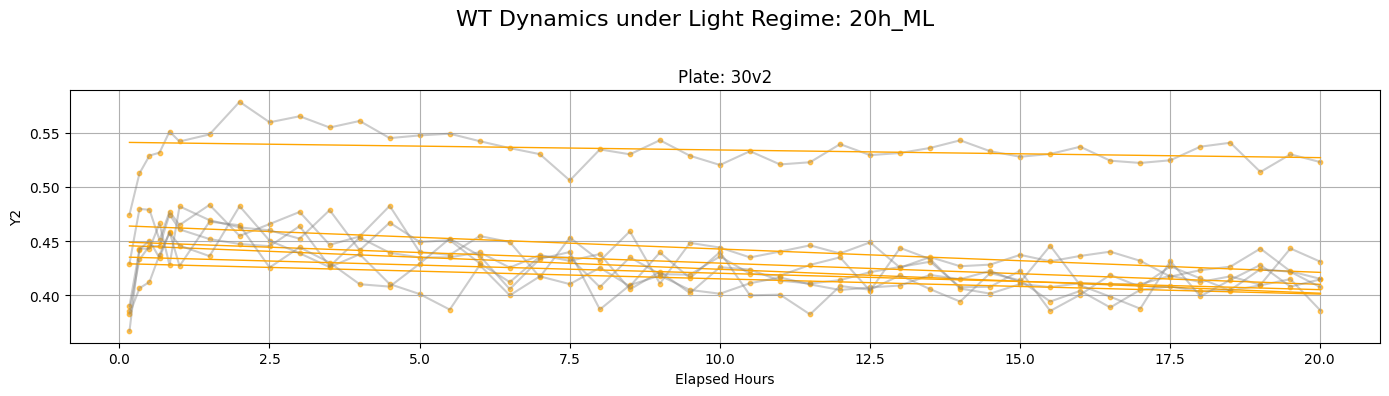

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# === Setup ===
y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
light_status_cols = [col for col in data.columns if col.startswith('light_status_')]

# Convert to elapsed hours
for col in time_columns:
    data[col] = pd.to_datetime(data[col], format='mixed')

elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)
elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]

data = data.drop(columns=[col for col in data.columns if col.startswith("elapsed_hours_")], errors='ignore')
data = pd.concat([data, elapsed_hours], axis=1)

elapsed_hours_cols = sorted(
    [col for col in data.columns if col.startswith("elapsed_hours_")],
    key=lambda x: int(x.split("_")[-1])
)

# === Plot for one light regime across all plates ===
light_regime = '20h_ML'
plates = ['30v2']#sorted(data[data['light_regime'] == light_regime]['plate'].unique())
n = len(plates)

fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(14, 4 * n), sharex=True)
if n == 1:
    axes = [axes]

for i, plate in enumerate(plates):
    ax = axes[i]
    data_plate = data[
        (data['light_regime'] == light_regime) &
        (data['plate'] == plate) &
        (data['mutant_ID'].isin(['WT', 'WT CLiP']))
    ]

    for _, row in data_plate.iterrows():
        y2_values = row[y2_columns].astype(float).values
        time_values = row[elapsed_hours_cols[1:]].astype(float).values
        light_status = row[light_status_cols[1:]].astype(str).values

        valid = ~np.isnan(time_values) & ~np.isnan(y2_values) & pd.notna(light_status)
        time_values = time_values[valid]
        y2_values = y2_values[valid]
        light_status = light_status[valid]

        ax.plot(time_values, y2_values, alpha=0.4, color='gray')
        ax.scatter(time_values[light_status == 'light'], y2_values[light_status == 'light'], color='orange', s=10, alpha=0.6)
        ax.scatter(time_values[light_status == 'dark'], y2_values[light_status == 'dark'], color='blue', s=10, alpha=0.6)

        for condition, color in zip(['light', 'dark'], ['orange', 'blue']):
            cond_mask = light_status == condition
            if cond_mask.sum() >= 2:
                x = time_values[cond_mask].reshape(-1, 1)
                y = y2_values[cond_mask]
                model = LinearRegression().fit(x, y)
                print(condition, model.coef_[0])
                x_line = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
                y_line = model.predict(x_line)
                ax.plot(x_line, y_line, color=color, linewidth=1)

    ax.set_title(f"Plate: {plate}")
    ax.set_ylabel("Y2")
    ax.grid(True)

axes[-1].set_xlabel("Elapsed Hours")
fig.suptitle(f"WT Dynamics under Light Regime: {light_regime}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [68]:
dataf = data[(data['plate']=='30v2') & (data['light_regime']=='20h_ML') & (data['mutant_ID'].isin(['WT', 'WT CLiP']))][['plate', 'light_regime', 'mutant_ID', 'y2_slope_light', 'y2_slope_dark']]
dataf

,plate,light_regime,mutant_ID,y2_slope_light,y2_slope_dark
2161,30v2,20h_ML,WT,-0.002160,NaN
2162,30v2,20h_ML,WT,-0.000710,NaN
2163,30v2,20h_ML,WT,-0.002213,NaN
2164,30v2,20h_ML,WT,-0.001962,NaN
2165,30v2,20h_ML,WT,-0.001408,NaN
2166,30v2,20h_ML,WT,-0.001513,NaN


In [ ]:
print(data[['plate', 'light_regime', 'mutant_ID', 'y2_slope_light', 'y2_slope_dark']].head())


In [73]:
from sklearn.linear_model import LinearRegression
import numpy as np
# Initialiser les colonnes pour stocker les pentes

df = data#pd.concat([data_30, data_31, data_32, data_33, data_99])
plates = np.sort(df['plate'].unique())
lights = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']   
df_list = []

for plate in plates :
    for light in lights : 
        data = df[df['plate'] == plate]
        data = data[data['light_regime'] == light]
        data['y2_slope_light'] = np.nan
        data['y2_slope_dark'] = np.nan

        # Identifier les colonnes nécessaires
        y2_cols = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
        # y2_idx = [int(col.split('_')[-1]) for col in y2_cols]
        # elapsed_cols = [f"elapsed_hours_{i+1}" for i in y2_idx]
        # light_status_cols = [f"light_status_{i}" for i in y2_idx]
        light_status_cols = [col for col in data.columns if col.startswith('light_status_')]
        y2_columns = [col for col in data.columns if col.startswith('y2_') and col.split('_')[-1].isdigit() and 'std' not in col]
        y2_cols = y2_columns
        time_columns = [col for col in data.columns if col.startswith('measurement_time_')]
        for col in time_columns:
            data[col] = pd.to_datetime(data[col], format='mixed')
        elapsed_hours = data[time_columns].apply(lambda row: (row - row.min()).dt.total_seconds() / 3600, axis=1)
        elapsed_hours.columns = [f'elapsed_hours_{i}' for i in range(len(elapsed_hours.columns))]
        data = data.drop(columns=[col for col in data.columns if col.startswith("elapsed_hours_")], errors='ignore')
        data = pd.concat([data, elapsed_hours], axis=1)
        elapsed_hours_cols = sorted(
            [col for col in data.columns if col.startswith("elapsed_hours_")],
            key=lambda x: int(x.split("_")[-1]))
        elapsed_cols = elapsed_hours_cols

        # Vérifier que toutes les colonnes nécessaires existent
        cols_exist = all(col in data.columns for col in elapsed_cols + light_status_cols)
        if not cols_exist:
            raise ValueError("Certaines colonnes elapsed_hours_ ou light_status_ sont manquantes.")

        # Fonction pour calculer les pentes
        def calculate_slopes(y2_values, time_values, light_status):
            slopes = {'y2_slope_light': np.nan, 'y2_slope_dark': np.nan}
            time_values = row[elapsed_hours_cols[1:]].astype(float).values
            light_status = row[light_status_cols[1:]].astype(str).values
            valid = ~np.isnan(y2_values) & ~np.isnan(time_values) & pd.notna(light_status)
            y2_values = y2_values[valid]
            time_values = time_values[valid]
            light_status = light_status[valid]

            for condition, key in zip(['light', 'dark'], ['y2_slope_light', 'y2_slope_dark']):
                mask = light_status == condition
                if np.sum(mask) >= 2:  # Nécessite au moins 2 points pour la régression
                    x = time_values[mask].reshape(-1, 1)
                    y = y2_values[mask]
                    model = LinearRegression().fit(x, y)
                    slopes[key] = model.coef_[0]
            return slopes

        # Calculer les pentes pour chaque ligne
        for idx, row in data.iterrows():
            y2_values = row[y2_cols].values.astype(float)
            time_values = row[elapsed_cols].values.astype(float)
            light_status = row[light_status_cols].values

            slopes = calculate_slopes(y2_values, time_values, light_status)
            data.at[idx, 'y2_slope_light'] = slopes['y2_slope_light']
            data.at[idx, 'y2_slope_dark'] = slopes['y2_slope_dark']
        df_list.append(data)
df_final = pd.concat(df_list, ignore_index=True)

In [74]:
#data['y2_slope'] = data[['y2_slope_light', 'y2_slope_dark']].mean(axis=1, skipna=True)
data = df_final.copy()
data['y2_slope'] = data['y2_slope_light']


In [75]:
data.to_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')
data

,Unnamed: 0,plate,measurement,start_date,light_regime,dark_threshold,light_threshold,num_frames,i,j,...,elapsed_hours_81,elapsed_hours_82,elapsed_hours_83,elapsed_hours_84,elapsed_hours_85,elapsed_hours_86,elapsed_hours_87,elapsed_hours_88,elapsed_hours_89,y2_slope
0,25946,30v1,M4,2024-06-11,20h_HL,15.467099,20.377613,92,11,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005391
1,25922,30v1,M4,2024-06-11,20h_HL,15.467099,20.377613,92,10,22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.003828
2,25921,30v1,M4,2024-06-11,20h_HL,15.467099,20.377613,92,10,21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.002502
3,25920,30v1,M4,2024-06-11,20h_HL,15.467099,20.377613,92,10,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.004578
4,25919,30v1,M4,2024-06-11,20h_HL,15.467099,20.377613,92,10,19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51273,71020,99v3,M5,2024-11-09,30s-30s,15.045673,21.309021,180,10,22,...,18.623889,18.6325,19.130278,19.138889,19.634167,19.642778,20.134722,20.143333,NaN,-0.003560
51274,71015,99v3,M5,2024-11-09,30s-30s,15.045673,21.309021,180,10,17,...,18.623889,18.6325,19.130278,19.138889,19.634167,19.642778,20.134722,20.143333,NaN,-0.003634
51275,71014,99v3,M5,2024-11-09,30s-30s,15.045673,21.309021,180,10,16,...,18.623889,18.6325,19.130278,19.138889,19.634167,19.642778,20.134722,20.143333,NaN,-0.004211
51276,71013,99v3,M5,2024-11-09,30s-30s,15.045673,21.309021,180,10,15,...,18.623889,18.6325,19.130278,19.138889,19.634167,19.642778,20.134722,20.143333,NaN,-0.003334


In [76]:
data['plate'].unique()

array(['30v1', '30v2', '30v3', '31v1', '31v2', '31v3', '32v1', '32v2',
       '32v3', '33v1', '33v2', '33v3', '98v1', '98v2', '98v3', '99',
       '99v1', '99v3'], dtype=object)

## Outlier test after light dark separation and debatching

In [5]:
data=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')
#data['y2_slope'] = data['y2_slope_mixed_centered']

/tmp/ipykernel_328360/959634943.py:1: DtypeWarning: Columns (326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,373,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope.csv')


In [22]:
data['plate'] = data['plate'].astype(str)

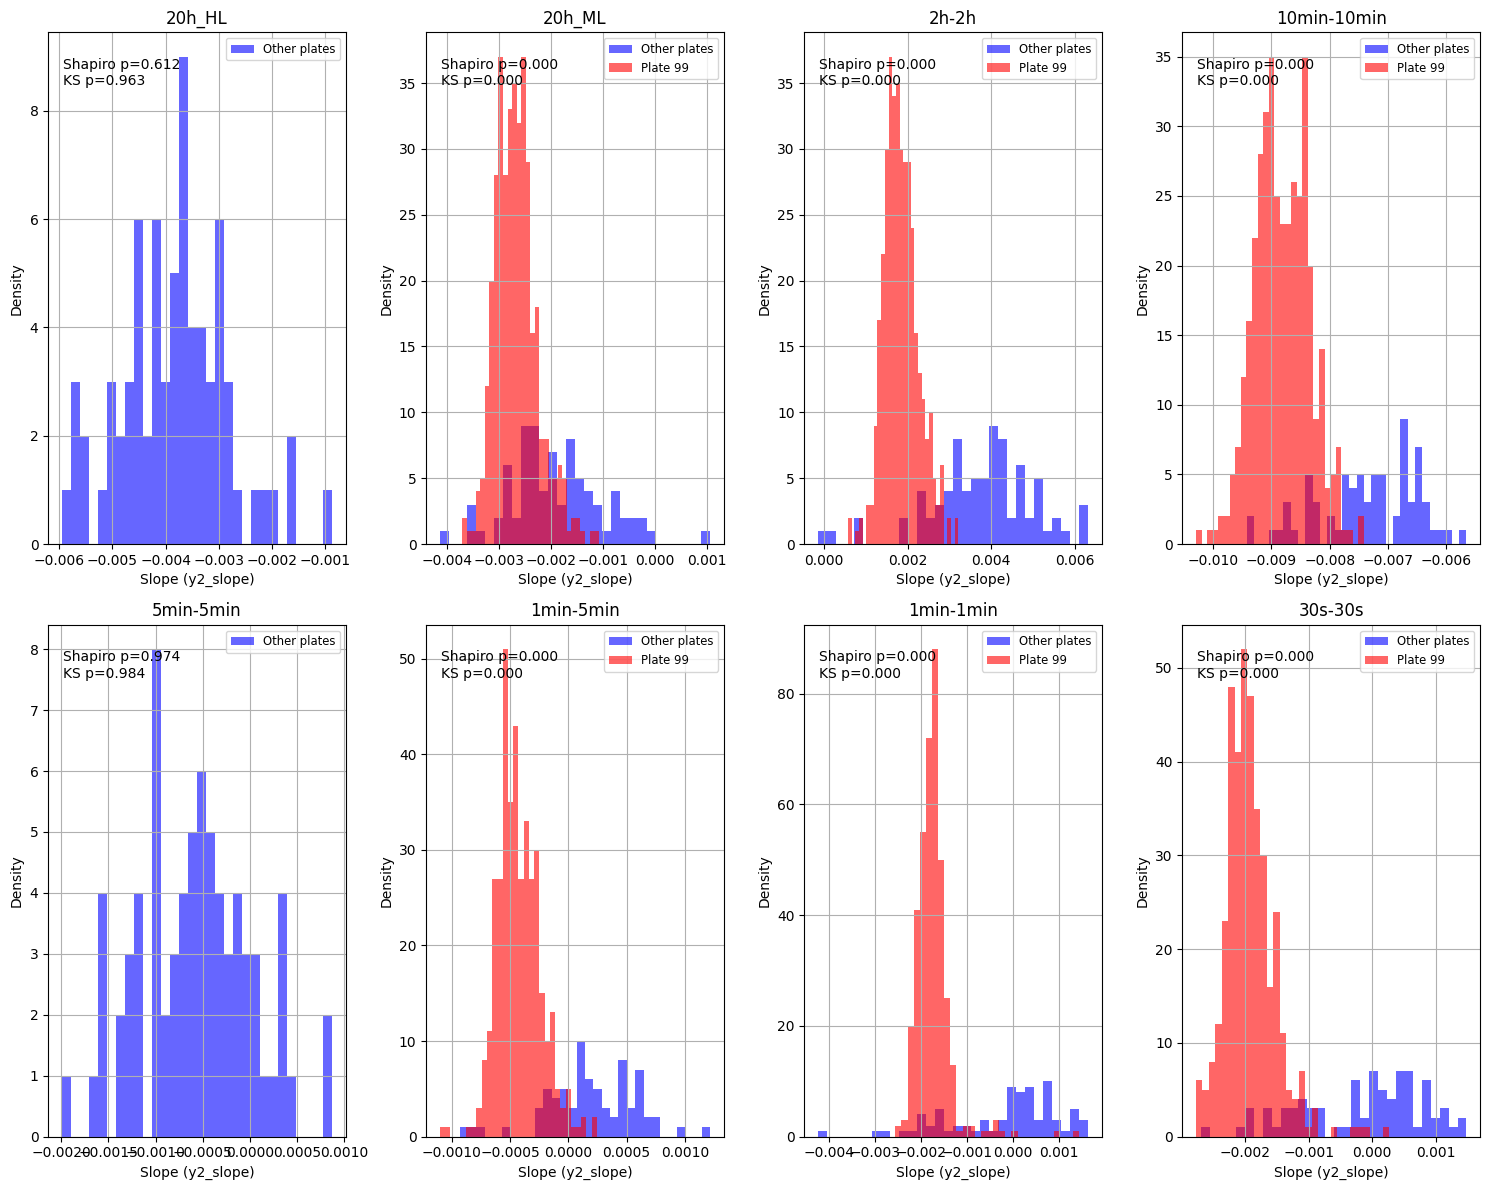

In [ ]:
from scipy.stats import norm, shapiro, kstest
import matplotlib.pyplot as plt
import numpy as np
normalised_wts = data[(data['mutant_ID'] == 'WT')]# & (data['plate']!='99')]

light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']


n_rows = 2
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 12))
axes = axes.flatten() 

for i, light_regime in enumerate(light_regimes):
    ax = axes[i]  
    data_light = normalised_wts[normalised_wts['light_regime'] == light_regime]
    
    # slopes = data_light['y2_slope'].dropna()
    slopes_99 = data_light[data_light['plate'] == '99']['y2_slope'].dropna()
    slopes_other = data_light[data_light['plate'].astype(str).str.startswith('3')]['y2_slope'].dropna()
    
    if slopes_99.empty and slopes_other.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(f'{light_regime}')
        ax.axis('off')
        continue

    if not slopes_other.empty:
        ax.hist(slopes_other, bins=30, alpha=0.6, color='blue', label='Other plates')

    if not slopes_99.empty:
        ax.hist(slopes_99, bins=30, alpha=0.6, color='red', label='Plate 99')

    slopes_combined = pd.concat([slopes_99, slopes_other])
    mean, std = norm.fit(slopes_combined)
    shapiro_stat, shapiro_p = shapiro(slopes_combined)
    ks_stat, ks_p = kstest(slopes_combined, 'norm', args=(mean, std))

    ax.text(0.05, 0.95, f'Shapiro p={shapiro_p:.3f}\nKS p={ks_p:.3f}', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top')
    
    ax.set_title(f'{light_regime}')
    ax.set_xlabel('Slope (y2_slope)')
    ax.set_ylabel('Density')
    ax.legend(fontsize='small')
    ax.grid(True)

for j in range(len(light_regimes), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
from scipy.stats import norm

wt_data = data[(data['plate'].astype(str).str.startswith('3')) & (data['mutant_ID'] == 'WT')]
non_wt_data = data[(data['plate'].astype(str).str.startswith('3')) & (data['mutant_ID'] == 'WT')]

mu_wt = wt_data['y2_slope'].mean()
sigma_wt = wt_data['y2_slope'].std() + non_wt_data['y2_slope'].std()

mutant_data = data[data['mutant_ID']!='WT']
mutant_data['z_score'] = (mutant_data['y2_slope'] - mu_wt) / sigma_wt
mutant_data['p_value'] = 2 * (1 - norm.cdf(np.abs(mutant_data['z_score'])))

#BH
mutant_data = mutant_data.sort_values('p_value')
mutant_data['rank'] = np.arange(1, len(mutant_data) + 1)
mutant_data['BH_threshold'] = (mutant_data['rank'] / len(mutant_data)) * 0.05
mutant_data['significant'] = mutant_data['p_value'] < mutant_data['BH_threshold']

print(mutant_data[['y2_slope', 'z_score', 'p_value', 'BH_threshold', 'significant']])

       y2_slope    z_score   p_value  BH_threshold  significant
23617 -0.014941 -11.442865  0.000000      0.000002         True
20381 -0.011745  -8.777244  0.000000      0.000003         True
20009 -0.012926  -9.762368  0.000000      0.000005         True
12140 -0.015250 -11.700382  0.000000      0.000007         True
14232  0.010073   9.419715  0.000000      0.000009         True
...         ...        ...       ...           ...          ...
15673 -0.001222  -0.000201  0.999840      0.049993        False
19009 -0.001221   0.000199  0.999841      0.049995        False
18974 -0.001222  -0.000161  0.999871      0.049997        False
18013 -0.001222  -0.000082  0.999935      0.049998        False
17155 -0.001221  -0.000067  0.999946      0.050000        False

[28866 rows x 5 columns]


/tmp/ipykernel_1331339/117921657.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutant_data['z_score'] = (mutant_data['y2_slope'] - mu_wt) / sigma_wt
/tmp/ipykernel_1331339/117921657.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mutant_data['p_value'] = 2 * (1 - norm.cdf(np.abs(mutant_data['z_score'])))
